In [184]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import cross_val_score, train_test_split, KFold
import optuna
import xgboost as xgb
from sklearn.feature_selection import mutual_info_regression

In [185]:
# https://www.kaggle.com/datasets/jocelyndumlao/actual-motor-vehicle-insurance-portfolio/data

# 1. Read the data

In [186]:
df = pd.read_csv("Motor vehicle insurance data.csv", sep=";", low_memory=False)

In [187]:
df.head()

,ID,Date_start_contract,Date_last_renewal,Date_next_renewal,Date_birth,Date_driving_licence,Distribution_channel,Seniority,Policies_in_force,Max_policies,...,Area,Second_driver,Year_matriculation,Power,Cylinder_capacity,Value_vehicle,N_doors,Type_fuel,Length,Weight
0,1,05/11/2015,05/11/2015,05/11/2016,15/04/1956,20/03/1976,0,4,1,2,...,0,0,2004,80,599,7068.0,0,P,NaN,190
1,1,05/11/2015,05/11/2016,05/11/2017,15/04/1956,20/03/1976,0,4,1,2,...,0,0,2004,80,599,7068.0,0,P,NaN,190
2,1,05/11/2015,05/11/2017,05/11/2018,15/04/1956,20/03/1976,0,4,2,2,...,0,0,2004,80,599,7068.0,0,P,NaN,190
3,1,05/11/2015,05/11/2018,05/11/2019,15/04/1956,20/03/1976,0,4,2,2,...,0,0,2004,80,599,7068.0,0,P,NaN,190
4,2,26/09/2017,26/09/2017,26/09/2018,15/04/1956,20/03/1976,0,4,2,2,...,0,0,2004,80,599,7068.0,0,P,NaN,190


# 2. Data wrangling

In [188]:
df.dtypes

ID                        int64
Date_start_contract      object
Date_last_renewal        object
Date_next_renewal        object
Date_birth               object
Date_driving_licence     object
Distribution_channel     object
Seniority                 int64
Policies_in_force         int64
Max_policies              int64
Max_products              int64
Lapse                     int64
Date_lapse               object
Payment                   int64
Premium                 float64
Cost_claims_year        float64
N_claims_year             int64
N_claims_history          int64
R_Claims_history        float64
Type_risk                 int64
Area                      int64
Second_driver             int64
Year_matriculation        int64
Power                     int64
Cylinder_capacity         int64
Value_vehicle           float64
N_doors                   int64
Type_fuel                object
Length                  float64
Weight                    int64
dtype: object

In [189]:
df.isna().sum()[df.isna().sum() > 0]

Date_lapse    70408
Type_fuel      1764
Length        10329
dtype: int64

In [190]:
# Create a boolean column "Contract_terminated"
df["Contract_terminated"] = df["Date_lapse"].notna()

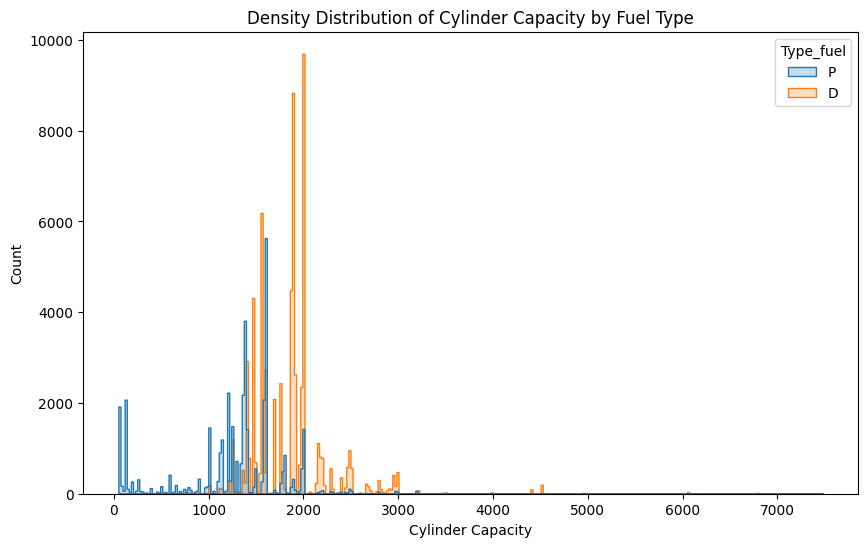

In [191]:
# Handle missing Type_fuel data

plt.figure(figsize=(10, 6))
sns.histplot(
    x="Cylinder_capacity",
    data=df,
    hue="Type_fuel",
    element="step",
)

plt.title("Density Distribution of Cylinder Capacity by Fuel Type")
plt.xlabel("Cylinder Capacity")
plt.show()

Diesel and petrol vehicles cluster in different cylinder-capacity bands, with diesel skewing toward larger engines and petrol toward smaller ones. This is why imputing missing Type_fuel from the modal fuel type per Cylinder_capacity bucket is a reasonable approach rather than just using the overall mode.

In [192]:
# Calculate the mode fuel type for each cylinder capacity
capacity_mode = df.groupby("Cylinder_capacity")["Type_fuel"].apply(
    lambda x: x.mode().iloc[0] if not x.mode().empty else None
)

# Map the modes back to fill the missing values
df["Type_fuel"] = df["Type_fuel"].fillna(df["Cylinder_capacity"].map(capacity_mode))

# Fill any leftover NaNs with the overall mode fuel type
df["Type_fuel"] = df["Type_fuel"].fillna(df["Type_fuel"].mode()[0])

In [193]:
# Fill missing lengths with the median of its specific vehicle category
df["Length"] = df.groupby("Type_risk")["Length"].transform(
    lambda x: x.fillna(x.median())
)

In [194]:
df.dtypes

ID                        int64
Date_start_contract      object
Date_last_renewal        object
Date_next_renewal        object
Date_birth               object
Date_driving_licence     object
Distribution_channel     object
Seniority                 int64
Policies_in_force         int64
Max_policies              int64
Max_products              int64
Lapse                     int64
Date_lapse               object
Payment                   int64
Premium                 float64
Cost_claims_year        float64
N_claims_year             int64
N_claims_history          int64
R_Claims_history        float64
Type_risk                 int64
Area                      int64
Second_driver             int64
Year_matriculation        int64
Power                     int64
Cylinder_capacity         int64
Value_vehicle           float64
N_doors                   int64
Type_fuel                object
Length                  float64
Weight                    int64
Contract_terminated        bool
dtype: o

In [195]:
# Anchor all date math to Date_last_renewal (the as-of date for each row's premium), instead of today's date
ref_date = pd.to_datetime(df["Date_last_renewal"], dayfirst=True)

df["Days_since_inception"] = (ref_date - pd.to_datetime(df["Date_start_contract"], dayfirst=True)).dt.days
df["Days_to_renewal"] = (pd.to_datetime(df["Date_next_renewal"], dayfirst=True) - ref_date).dt.days
df["Insurer_age"] = ref_date.dt.year - pd.to_datetime(df["Date_birth"], dayfirst=True).dt.year
df["Licence_age"] = ref_date.dt.year - pd.to_datetime(df["Date_driving_licence"], dayfirst=True).dt.year
df["Vehicle_age"] = ref_date.dt.year - df["Year_matriculation"]
df = df.drop(columns=["Year_matriculation"])

In [196]:
df["Distribution_channel"].unique()

array(['0', '1', '00/01/1900'], dtype=object)

In [197]:
df["Distribution_channel"] = pd.to_numeric(df["Distribution_channel"], errors='coerce')

In [198]:
# Fill NaN values with median
distribution_channel_median = df["Distribution_channel"].median()
df["Distribution_channel"] = df["Distribution_channel"].fillna(distribution_channel_median)
df["Distribution_channel"] = df["Distribution_channel"].astype("int32")

In [199]:
df["Distribution_channel"].unique()

array([0, 1], dtype=int32)

The raw Distribution_channel column contained a corrupted value, '00/01/1900', which may be a date-parsing artifact from Excel on the source file. Coercing to numeric and filling with the median safely handles it.

In [200]:
# Perform one-hot-encoding for categorical non-ordinal columns
categorical_cols = ["Distribution_channel", "Payment", "Type_risk", "Area", "Second_driver", "Type_fuel"]
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [201]:
df.dtypes

ID                          int64
Date_start_contract        object
Date_last_renewal          object
Date_next_renewal          object
Date_birth                 object
Date_driving_licence       object
Seniority                   int64
Policies_in_force           int64
Max_policies                int64
Max_products                int64
Lapse                       int64
Date_lapse                 object
Premium                   float64
Cost_claims_year          float64
N_claims_year               int64
N_claims_history            int64
R_Claims_history          float64
Power                       int64
Cylinder_capacity           int64
Value_vehicle             float64
N_doors                     int64
Length                    float64
Weight                      int64
Contract_terminated          bool
Days_since_inception        int64
Days_to_renewal             int64
Insurer_age                 int32
Licence_age                 int32
Vehicle_age                 int64
Distribution_c

In [202]:
df_non_obj = df.select_dtypes(exclude="object")
df_non_obj.dtypes

ID                          int64
Seniority                   int64
Policies_in_force           int64
Max_policies                int64
Max_products                int64
Lapse                       int64
Premium                   float64
Cost_claims_year          float64
N_claims_year               int64
N_claims_history            int64
R_Claims_history          float64
Power                       int64
Cylinder_capacity           int64
Value_vehicle             float64
N_doors                     int64
Length                    float64
Weight                      int64
Contract_terminated          bool
Days_since_inception        int64
Days_to_renewal             int64
Insurer_age                 int32
Licence_age                 int32
Vehicle_age                 int64
Distribution_channel_1       bool
Payment_1                    bool
Type_risk_2                  bool
Type_risk_3                  bool
Type_risk_4                  bool
Area_1                       bool
Second_driver_

# 3. Exploratory Data Analysis

In [203]:
df_numeric = df_non_obj.select_dtypes(exclude="bool").drop(columns="ID")
corr_data = df_numeric.corr()["Premium"].drop("Premium").sort_values(ascending=False)
corr_data

Power                   0.431741
Value_vehicle           0.415204
N_doors                 0.341438
Length                  0.317101
Weight                  0.298807
Cylinder_capacity       0.277018
R_Claims_history        0.174721
N_claims_history        0.117130
N_claims_year           0.092688
Lapse                   0.055217
Cost_claims_year        0.053662
Days_to_renewal         0.002426
Days_since_inception   -0.065109
Seniority              -0.069821
Max_policies           -0.077578
Max_products           -0.090041
Policies_in_force      -0.092465
Licence_age            -0.114240
Insurer_age            -0.115842
Vehicle_age            -0.310018
Name: Premium, dtype: float64

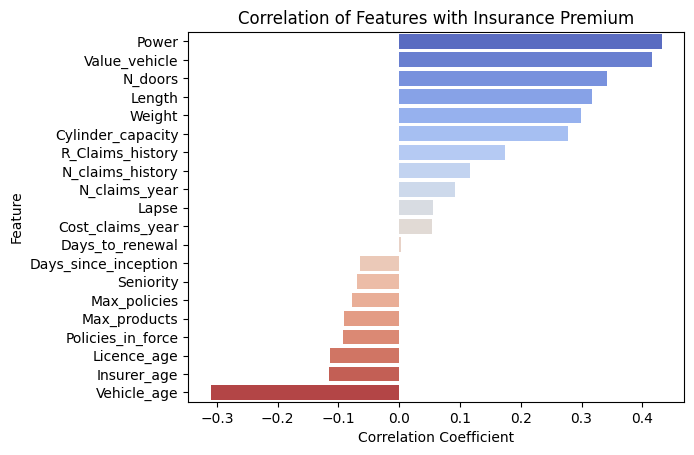

In [204]:
# Visualization of correlations
sns.barplot(x=corr_data.values, y=corr_data.index, hue=corr_data.index, palette="coolwarm")
plt.title("Correlation of Features with Insurance Premium")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Feature")
plt.show()

Premium correlates most strongly with vehicle characteristics of Power (0.43), Value_vehicle (0.42) and N_doors (0.34). Premium correlates most negatively with Vehicle_age (-0.31), meaning that newer, more powerful, more valuable vehicles command higher premiums while older vehicles are less expensive to insure. Claims-related fields (R_Claims_history, N_claims_history) correlate only weakly, suggesting this insurer prices primarily based on vehicle risk rather than individual claims history.

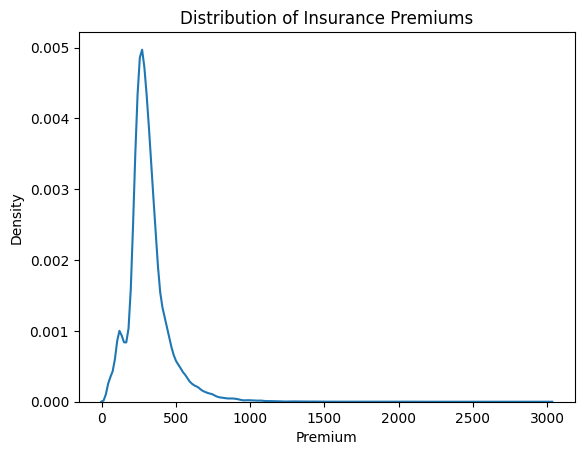

In [205]:
sns.kdeplot(df["Premium"])
plt.title("Distribution of Insurance Premiums")
plt.show()

Premiums are right-skewed with a sharp peak around 250-300€ and a long tail out to around 3000€, which is why the model later predicts log1p(Premium) rather than raw Premium, which is a standard approach for skewed monetary targets.

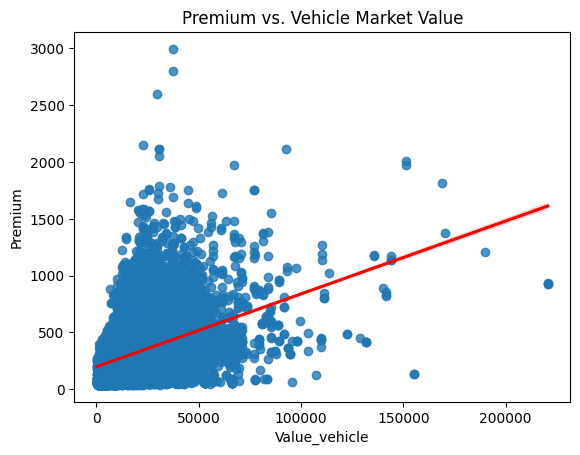

In [206]:
sns.regplot(x="Value_vehicle", y="Premium", data=df, line_kws={"color": "red"})
plt.title("Premium vs. Vehicle Market Value")
plt.show()

Text(0.5, 1.0, 'Premium vs. Vehicle Power')

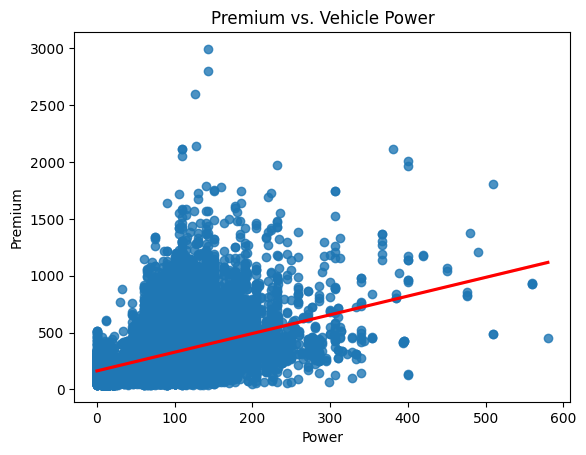

In [207]:
sns.regplot(x="Power", y="Premium", data=df, line_kws={"color": "red"})
plt.title("Premium vs. Vehicle Power")

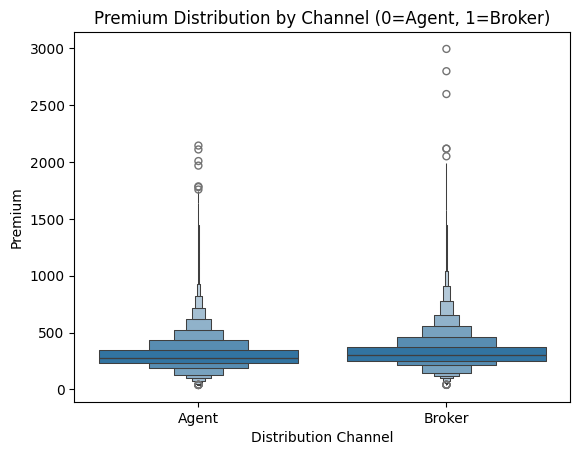

In [208]:
sns.boxenplot(data=df, x="Distribution_channel_1", y="Premium")
plt.title("Premium Distribution by Channel (0=Agent, 1=Broker)")
plt.xticks([0, 1], ["Agent", "Broker"])
plt.xlabel("Distribution Channel")
plt.show()

Median premiums are nearly identical between Agent and Broker channels, but the broker channel shows a wider spread and more high-value outliers. Brokers may be placing a more heterogeneous mix of vehicles (or higher-risk ones) than agents.

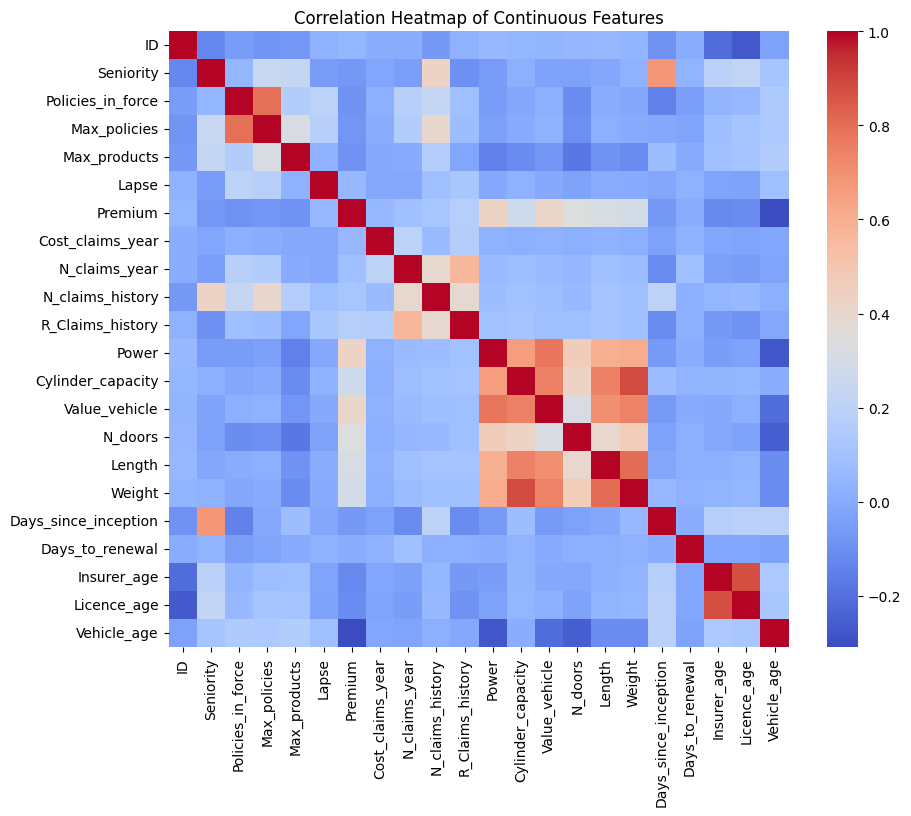

In [209]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include=['int', 'float']).corr(), cmap='coolwarm', annot=False)
plt.title('Correlation Heatmap of Continuous Features')
plt.show()

Text(0.5, 1.0, 'Age-based Premium Trend')

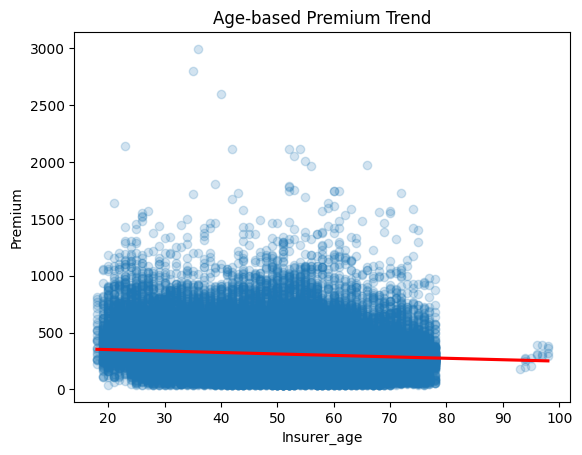

In [210]:
sns.regplot(x="Insurer_age", y="Premium", data=df, scatter_kws={"alpha":0.2}, line_kws={"color":"red"})
plt.title("Age-based Premium Trend")

Text(0.5, 1.0, 'Premium vs. Claims History')

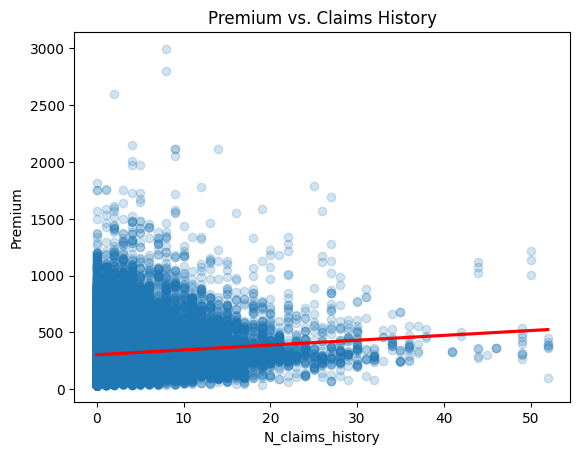

In [211]:
sns.regplot(x="N_claims_history", y="Premium", data=df, scatter_kws={"alpha":0.2}, line_kws={"color":"red"})
plt.title("Premium vs. Claims History")

Despite the wide scatter, there's a mild positive trend between N_claims_history and Premium, customers with more historical claims tend to pay somewhat more, but the relationship is much weaker than the link to vehicle value or power, reinforcing that this insurer's pricing leans on the vehicle being insured more than the claims record.

# 4. Model development

In [213]:
# 4.1 Train test split

# Drop columns in addition to ID column to avoid target leakage
cols_to_drop = ["ID", "Cost_claims_year", "N_claims_year"]
X = df.copy().drop(columns=cols_to_drop).select_dtypes(exclude="object")
y = X.pop("Premium")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [214]:
def make_mi_scores(X, y, discrete_features):
    mi_scores = mutual_info_regression(
        X,
        y,
        discrete_features=discrete_features,
        random_state=0
    )
    mi_scores = pd.Series(mi_scores, index=X.columns, name="MI Score")
    return mi_scores.sort_values(ascending=False)

# Continuous features
continuous_features = [
    "Insurer_age",
    "Licence_age",
    "Vehicle_age",
    "Seniority", 
    "Premium",
    "Value_vehicle",
    "Length",
    "Weight",
    "Cylinder_capacity",
    "Cost_claims_year"
]

# Everything else numeric is treated as discrete
discrete_mask = [
    col not in continuous_features for col in X_train.columns
]

mi_scores = make_mi_scores(X_train, y_train.loc[X_train.index], discrete_mask)

In [216]:
mi_scores.sort_values(ascending=False)

Cylinder_capacity         0.329465
Value_vehicle             0.326760
Length                    0.325882
Weight                    0.321306
Power                     0.310905
N_doors                   0.210504
Type_risk_3               0.104392
R_Claims_history          0.103018
Vehicle_age               0.097977
Payment_1                 0.074937
Seniority                 0.070522
Type_fuel_P               0.065050
N_claims_history          0.051021
Days_since_inception      0.046365
Type_risk_4               0.034452
Max_policies              0.034054
Policies_in_force         0.027389
Licence_age               0.026348
Insurer_age               0.025150
Distribution_channel_1    0.022411
Second_driver_1           0.020917
Contract_terminated       0.018888
Area_1                    0.017577
Max_products              0.016912
Type_risk_2               0.014293
Lapse                     0.006440
Days_to_renewal           0.003500
Name: MI Score, dtype: float64

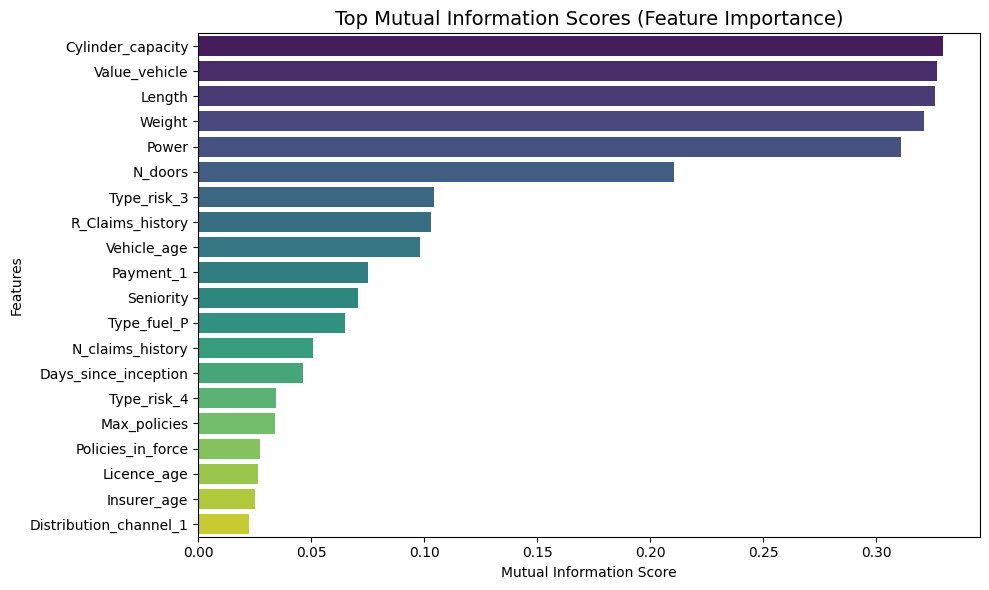

In [217]:
top_n = 20
plot_data = mi_scores.head(top_n).sort_values(ascending=False)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=plot_data.values,
    y=plot_data.index,
    hue=plot_data.index,
    palette="viridis"
)

plt.title("Top Mutual Information Scores (Feature Importance)", fontsize=14)
plt.xlabel("Mutual Information Score")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

Mutual information ranks vehicle features Cylinder_capacity, Value_vehicle, Length, Weight, and Power as the strongest predictors of Premium, consistent with the correlation analysis, but MI also picks up a nonlinear signal from R_Claims_history and Vehicle_age that simple linear correlation underweights.

In [218]:
# 4.2 Optuna objective
CV = KFold(n_splits=5, shuffle=True, random_state=42)

def objective(trial):
    params = {
        "n_estimators":       trial.suggest_int("n_estimators", 400, 1200),
        "max_depth":          trial.suggest_int("max_depth", 3, 10),
        "learning_rate":      trial.suggest_float("learning_rate", 0.001, 0.3, log=True),
        "subsample":          trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree":   trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight":   trial.suggest_int("min_child_weight", 1, 10),
        "reg_alpha":          trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda":         trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "gamma":              trial.suggest_float("gamma", 0.0, 5.0),
        "tree_method": "hist",
        "random_state": 42,
        "n_jobs": -1,
    }

    model = xgb.XGBRegressor(**params)    

    scores = cross_val_score(
        model,
        X_train,
        np.log1p(y_train), # Log because Premium is skewed
        scoring="neg_root_mean_squared_error",
        cv=CV,
        n_jobs=-1
    )
    return -scores.mean()

In [219]:
# 4.3 Run study
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50)

print(f"\nBest RMSE : {study.best_value:.5f}")
print("Best params:", study.best_params)

[I 2026-06-23 21:18:33,381] A new study created in memory with name: no-name-4dcdc59d-c1cb-4906-ae25-6b332f52bb40
[I 2026-06-23 21:18:46,129] Trial 0 finished with value: 0.2724251388147735 and parameters: {'n_estimators': 1136, 'max_depth': 9, 'learning_rate': 0.007006882848297959, 'subsample': 0.5746424826127363, 'colsample_bytree': 0.8124931621627365, 'min_child_weight': 7, 'reg_alpha': 4.884233131364226, 'reg_lambda': 0.0368373785966947, 'gamma': 1.6449484905774097}. Best is trial 0 with value: 0.2724251388147735.
[I 2026-06-23 21:18:52,509] Trial 1 finished with value: 0.26615968219821917 and parameters: {'n_estimators': 433, 'max_depth': 8, 'learning_rate': 0.016390726842842627, 'subsample': 0.5061247288750944, 'colsample_bytree': 0.8623135738405496, 'min_child_weight': 2, 'reg_alpha': 1.7788985250602867e-05, 'reg_lambda': 3.702638223364215e-08, 'gamma': 1.0415267608680363}. Best is trial 1 with value: 0.26615968219821917.
[I 2026-06-23 21:19:00,457] Trial 2 finished with value: 


Best RMSE : 0.25264
Best params: {'n_estimators': 400, 'max_depth': 10, 'learning_rate': 0.018741473636581903, 'subsample': 0.5559678135611055, 'colsample_bytree': 0.7326033417828007, 'min_child_weight': 8, 'reg_alpha': 0.0030979592913112763, 'reg_lambda': 1.0214345758910737e-08, 'gamma': 0.1539351434989713}


In [ ]:
# 4.4 Final model with the best parameters and full training data
best_model = xgb.XGBRegressor(**study.best_params, tree_method="hist", random_state=42, n_jobs=-1)

best_model.fit(X_train, np.log1p(y_train))

cv_rmsle = -cross_val_score(
    best_model,
    X_train,
    np.log1p(y_train),
    scoring="neg_root_mean_squared_error",
    cv=CV,
    n_jobs=-1
).mean()

print(f"CV RMSE: {cv_rmsle:.5f}")

CV RMSE: 0.25264


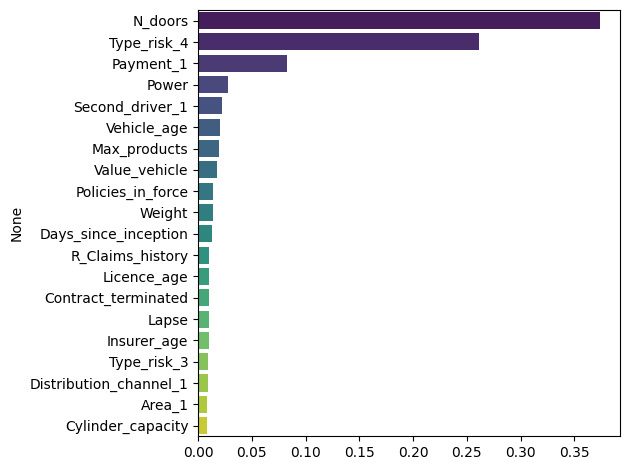

In [221]:
# 4.5 Feature importance
importances = pd.Series(
    best_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False).head(20)

sns.barplot(
    x=importances.values,
    y=importances.index,
    hue=importances.index,
    palette="viridis"
)

plt.tight_layout()
plt.show()

N_doors is clearly the most important feature in the tuned XGBoost model, far outweighing Power and Value_vehicle despite those having higher raw correlation with Premium. Given that N_doors ranges from 0–6 in this dataset, it's likely acting as a proxy for vehicle category rather than being a genuine economic driver of price on its own.

In [222]:
# 4.6 Generate predictions
predictions = np.expm1(best_model.predict(X_test))

result = pd.DataFrame({
    "actual": y_test,
    "predicted": predictions
})

result["error"] = result["predicted"] - result["actual"]
result["error_pct"] = result["error"] / result["actual"].replace(0, np.nan)
result.describe()

,actual,predicted,error,error_pct
count,21111.000000,21111.000000,21111.000000,21111.000000
mean,314.749813,303.369507,-11.380313,0.033765
std,138.242458,92.184059,92.336741,0.317396
min,40.260000,39.585094,-1397.588309,-0.772238
25%,242.000000,260.176147,-38.958510,-0.121876
50%,292.200000,298.794525,2.510781,0.010259
75%,360.235000,345.028580,36.835309,0.146415
max,1972.480000,1098.699097,432.482046,6.616263


<Axes: xlabel='error_pct', ylabel='Count'>

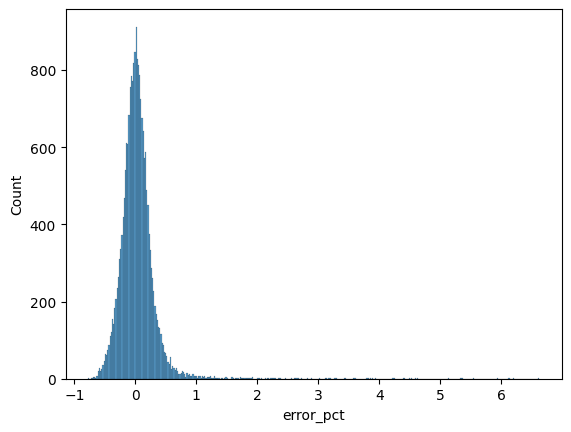

In [224]:
sns.histplot(result["error_pct"])

<Axes: xlabel='actual', ylabel='Count'>

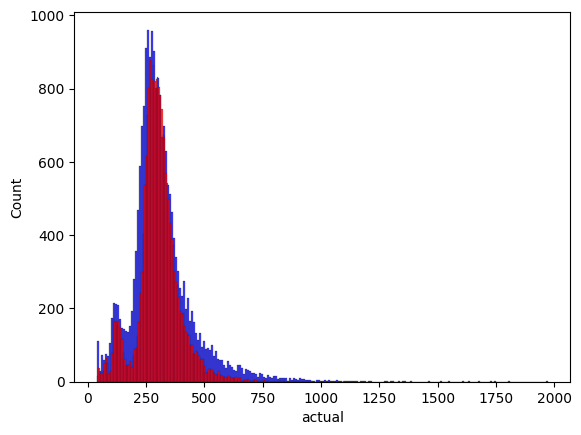

In [226]:
sns.histplot(result["actual"], color="blue", label="Actual")
sns.histplot(result["predicted"], color="red", label="Predicted")

On the held-out test set, predictions track actual premiums closely on average (mean error of about -11€, or +3.4%), with median error of +2.51€ or +1.0%. The error distribution does have a long tail due to few large misses.

## 5. Summary of Findings

This analysis modeled motor vehicle insurance premiums from an actual insurer, combining data cleaning, exploratory analysis, and a tuned XGBoost regressor.

**Data quality** The raw data required cleanup before modeling: a corrupted date-like value in `Distribution_channel`, missing fuel types (imputed from the modal fuel type within each cylinder-capacity band), and missing vehicle lengths (imputed by vehicle category). All date fields were anchored to each row's `Date_last_renewal` rather than today's date, since Premium reflects the policy as it stood at that renewal.

**What drives premiums** Vehicle characteristics dominate pricing far more than driver risk history. `Power`, `Value_vehicle`, and vehicle variables `Length`, `Weight`, `Cylinder_capacity` are the strongest linear correlates of Premium, while claims history (`N_claims_history`, `R_Claims_history`) correlates only weakly. The tuned XGBoost model goes further by leaning heavily on `N_doors`, which most likely behaves as a stand-in for the vehicle category (`Type_risk`) rather than a true price driver in its own right. This suggests that the categorical vehicle-type signal is doing more work than the continuous "risk history" fields that the insurer might assume to matter more.

**Model performance** After log-transforming the right-skewed Premium target and tuning hyperparameters with Optuna (5-fold CV, 50 trials), the final XGBoost model reached a cross-validated RMSE of approximately 0.25 on the log scale. On the held-out test set, predictions were on average within around 3.4% of the actual premium, with median error of +2.51€ or +1.0%, which is solid performance, though the error distribution has a long right tail concentrated in the highest-premium policies, suggesting room for a follow-up model (or a separate high-value-policy segment) focused specifically on that tail.